# Patterned Loading Sim
This is an implementation of the Patterned Loading feature. For the design specification please see the document Specification.md.

Ultimately, these tools will be used to reproduce the Patterned Loading experiments explained in the paper by S. Peil
1. Peil, S. & Porto, J. & Tolra, & Laburthe, B. & Obrecht, John & King, B. & Subbotin, M. & Rolston, Steven & Phillips, William. (2003). Patterned loading of a Bose-Einstein condensate into an optical lattice. Phys. Rev. A. 67. 051603. 10.1103/PhysRevA.67.051603. 

In [1]:
from oqtant.schemas.quantum_matter import QuantumMatterFactory
from oqtant.schemas.quantum_matter import QuantumMatter as qm
from oqtant.schemas.output import Gaussian_dist_2D
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import scipy.optimize as opt
from IPython.display import HTML

qmf = QuantumMatterFactory()
qmf.get_login()

Auth(children=(HBox(children=(Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\x12\x00\x00\x00\xc…

In [2]:
qmf.get_client()

Job Limits:
╒═══════════════╤═══════════════════╤════════════════════╤════════════════════╕
│   Daily Limit │   Daily Remaining │   Standard Credits │   Priority Credits │
╞═══════════════╪═══════════════════╪════════════════════╪════════════════════╡
│            20 │                20 │                 64 │                  0 │
╘═══════════════╧═══════════════════╧════════════════════╧════════════════════╛


In [3]:
from PatternedLoadingPkg.patterned_loader import PatternedLoader

In [83]:
recoilE = 3.8
shortPot = 12*recoilE
longPot = 5*recoilE
shortPot

45.599999999999994

### Experiment 1: Superlattice

In [84]:
pl = PatternedLoader(qmf)

s_pot = shortPot #kHz
s_delay = 2. #ms
s_rise = 2. #ms also fall
s_hold = 2. #ms
short = pl.Lattice()
short.set_potential(s_pot)
short.set_loading_seq(s_delay, s_rise, s_hold)

l_pot = longPot #kHz
l_delay = 0. #ms
l_rise = 2. #ms also fall
l_hold = 2. #ms
long = pl.Lattice()

long.set_potential(l_pot)
long.set_loading_seq(l_delay, l_rise, l_hold)

pl.set_superlattice(long, short)

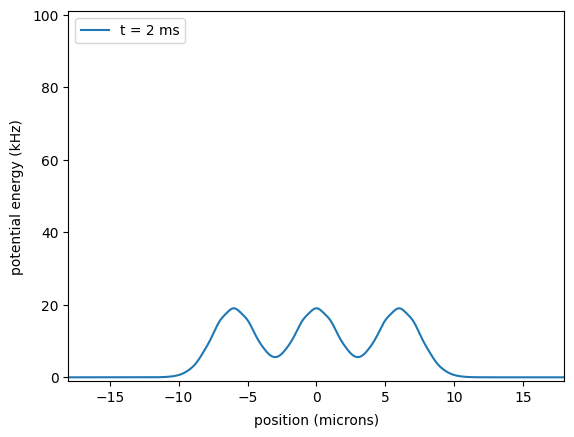

In [85]:
pl.get_matter("t").show_potential(times=[2], include_ideal=False, include_magnetic=False, xlimits=[-18,18])

In [86]:
repeats = 1
jobs = []
for rep in range(repeats):
    name = "SuperlatticeSim_it_big" + "_rep_" + str(rep)
    jobs.append(pl.get_matter(name))

In [87]:
sim = True
track = False
if sim == False:
    track = True
[matter.submit(track=track, sim=sim) for matter in jobs]

submitted simulation


[None]

In [88]:
superl = [matter.get_result() for matter in jobs]

ground state calculation in progress       
ground state calculation complete          
trapped simulation in progress             
Condensate hit top boundary at time:   4.616609180153888
trapped simulation complete                   
Simulation complete.
Results may be invalid after atoms reached simulation boundaries. Consider reducing barrier height or increasing ramp/evolution time.


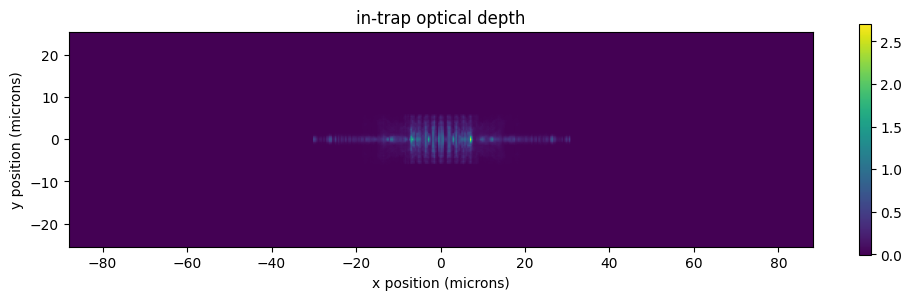

In [89]:
jobs[0].output.plot_it()

In [90]:
import os
home = os.path.expanduser("~")
for matter in jobs:
    data_path = f"{home}\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\sim\\{matter.name}.txt"
    matter.write_to_file(file_path=data_path)

Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\sim\SuperlatticeSim_it_big_rep_0.txt"


### Experiment 2: Long Only

In [91]:
pl = PatternedLoader(qmf, "LongOnlySim")

s_pot = 0.0 #kHz
s_delay = 2. #ms
s_rise = 2. #ms also fall
s_hold = 2. #ms
short = pl.Lattice()
short.set_potential(s_pot)
short.set_loading_seq(s_delay, s_rise, s_hold)

l_pot = longPot #kHz
l_delay = 0. #ms
l_rise = 2. #ms also fall
l_hold = 2. #ms
long = pl.Lattice()

long.set_potential(l_pot)
long.set_loading_seq(l_delay, l_rise, l_hold)

pl.set_superlattice(long, short)

In [92]:
repeats = 1
jobs = []
for rep in range(repeats):
    name = "LongOnlySim_it_big" + "_rep_" + str(rep)
    jobs.append(pl.get_matter(name))

In [93]:
sim = True
track = False
if sim == False:
    track = True
[matter.submit(track=track, sim=sim) for matter in jobs]

submitted simulation


[None]

In [94]:
[matter.get_result() for matter in jobs]

ground state calculation in progress       
ground state calculation complete          
trapped simulation in progress             
Condensate hit left boundary at time:   5.730963120191033
Condensate hit right boundary at time:   5.730963120191033
trapped simulation complete                   
Simulation complete.
Results may be invalid after atoms reached simulation boundaries. Consider reducing barrier height or increasing ramp/evolution time.


[None]

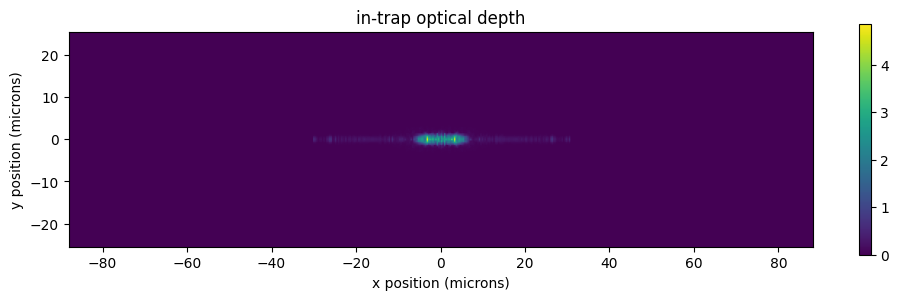

In [95]:
jobs[0].output.plot_it()

In [96]:
import os
home = os.path.expanduser("~")
for matter in jobs:
    data_path = f"{home}\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\sim\\{matter.name}.txt"
    matter.write_to_file(file_path=data_path)

Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\sim\LongOnlySim_it_big_rep_0.txt"


### Experiment 3: Short Only

In [97]:
pl = PatternedLoader(qmf, "ShortOnlySim")

s_pot = shortPot #kHz
s_delay = 2. #ms
s_rise = 2. #ms also fall
s_hold = 2. #ms
short = pl.Lattice()
short.set_potential(s_pot)
short.set_loading_seq(s_delay, s_rise, s_hold)

l_pot = 0. #kHz
l_delay = 0. #ms
l_rise = 2. #ms also fall
l_hold = 2. #ms
long = pl.Lattice()

long.set_potential(l_pot)
long.set_loading_seq(l_delay, l_rise, l_hold)

pl.set_superlattice(long, short)

In [98]:
repeats = 1
jobs = []
for rep in range(repeats):
    name = "ShortOnlySim_it_big" + "_rep_" + str(rep)
    jobs.append(pl.get_matter(name))

In [99]:
sim = True
track = False
if sim == False:
    track = True
[matter.submit(track=track, sim=sim) for matter in jobs]

submitted simulation


[None]

In [100]:
[matter.get_result() for matter in jobs]

ground state calculation in progress       
ground state calculation complete          
trapped simulation in progress             
trapped simulation complete                   
Simulation complete.


[None]

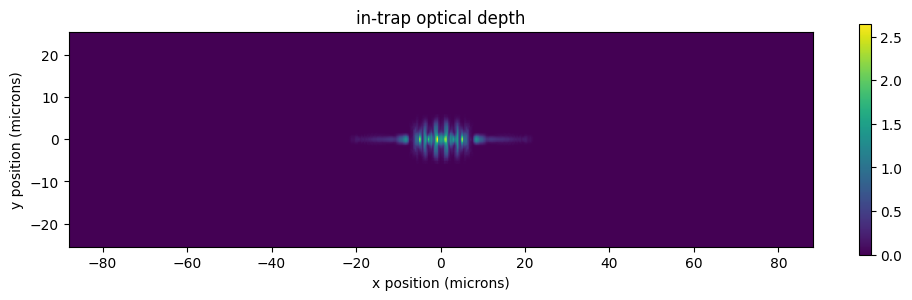

In [101]:
jobs[0].output.plot_it()

In [102]:
import os
home = os.path.expanduser("~")
for matter in jobs:
    data_path = f"{home}\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\sim\\{matter.name}.txt"
    matter.write_to_file(file_path=data_path)

Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\sim\ShortOnlySim_it_big_rep_0.txt"
